In [71]:
import pandas as pd
import networkx as nx
import nltk
import ast
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from collections import Counter
import math
from wordcloud import WordCloud
import matplotlib.pyplot as plt



# Community assignments (already saved)
community_df = pd.read_csv('../Week6/author_communities.csv')

# Degrees of authors and merging with community assignments
community_df

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/oskarkarlsson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,author_id,community,degree
0,https://openalex.org/A5090665793,0,8
1,https://openalex.org/A5113226689,0,35
2,https://openalex.org/A5058815871,3,9
3,https://openalex.org/A5040821463,3,6
4,https://openalex.org/A5000679279,3,79
...,...,...,...
461,https://openalex.org/A5015788232,6,4
462,https://openalex.org/A5043075977,6,4
463,https://openalex.org/A5037829144,6,4
464,https://openalex.org/A5039596937,6,3


# Exercise 1

In [ ]:
# 2.
# importing the dataset with abstracts
abstracts_df = pd.read_csv('../Week5/D2_temp_papers.csv')

# Defining a function that converts inverted index string to abstracts
def inverted_index_to_text(inv_idx_str):
    if pd.isna(inv_idx_str):
        return ''
    inv_idx = ast.literal_eval(inv_idx_str)
    words = [''] * (max(max(pos) for pos in inv_idx.values()) + 1)
    for word, positions in inv_idx.items():
        for pos in positions:
            words[pos] = word
    return ' '.join(words)



Politics and political conflict often occur in the written and spoken word. Scholars have long recognized this, but the massive costs of analyzing even moderately sized collections of texts have hindered their use in political science research. Here lies the promise of automated text analysis: it substantially reduces the costs of analyzing large collections of text. We provide a guide to this exciting new area of research and show how, in many instances, the methods have already obtained part of their promise. But there are pitfalls to using automated methods—they are no substitute for careful thought and close reading and require extensive and problem-specific validation. We survey a wide range of new methods, provide guidance on how to validate the output of the models, and clarify misconceptions and errors in the literature. To conclude, we argue that for automated text methods to become a standard tool for political scientists, methodologists must contribute new methods and new me

In [ ]:
abstracts_df = pd.read_csv('../Week5/D2_temp_papers.csv')
abstracts_df['author_ids'] = abstracts_df['author_ids'].apply(ast.literal_eval)

# Explode so each row has one author
exploded = abstracts_df.explode('author_ids')
exploded['author_ids'] = exploded['author_ids'].str.strip()

# Merge with community assignments dataframe
merged = exploded.merge(community_df, left_on='author_ids', right_on='author_id') # this contains all abstracts with their corresponding community

# Convert abstracts to text and tokenize
merged['text'] = merged['abstract_inverted_index'].apply(inverted_index_to_text)

stop_words = set(stopwords.words('english')) # removes common words like the, is, at etc.

def tokenize(text):
    tokens = word_tokenize(text.lower())
    return [w for w in tokens if w not in stop_words and w not in string.punctuation]

# Group by community and combine all tokens into one document
community_docs = merged.groupby('community')['text'].apply(lambda texts: tokenize(' '.join(texts))).to_dict()

for comm, tokens in community_docs.items():
    print(f"Community {comm}: {len(tokens)} tokens")

Community 0: 7318 tokens
Community 1: 742 tokens
Community 2: 907 tokens
Community 3: 21965 tokens
Community 4: 9660 tokens
Community 5: 950 tokens
Community 6: 25316 tokens
Community 7: 326 tokens
Community 8: 3838 tokens
Community 9: 5020 tokens
Community 10: 4611 tokens
Community 11: 2095 tokens
Community 12: 0 tokens


In [62]:
# 3.
# Finding the top communities by author count
top_communities = community_df['community'].value_counts().head(5).index.tolist()

# Calculating term frequencies for the top communities
tf_community = {}
for comm, tokens in community_docs.items():
    word_counts = Counter(tokens)
    total = len(tokens)
    tf_community[comm] = {word: count / total for word, count in word_counts.items()}

# Finding the top 5 terms in each of the top communities
for comm in top_communities:
    top_terms = sorted(tf_community[comm].items(), key=lambda x: x[1], reverse=True)[:5] # sorts by highest frequency and takes the top 5
    print(f"Top terms for Community {comm}: {[term for term, _ in top_terms]}")

Top terms for Community 6: ['social', 'network', 'organizational', 'research', 'organizations']
Top terms for Community 3: ['social', 'find', 'experiments', 'consumption', '``']
Top terms for Community 4: ['social', 'people', 'effects', 'vaccine', 'information']
Top terms for Community 9: ['coverage', 'media', 'funding', 'female', 'women']
Top terms for Community 0: ['political', 'social', 'text', 'data', '—']


In [67]:
# Calculating IDF for each word for top 5 communities
idf = {}
N = len(top_communities)
for comm in top_communities:
    for word in tf_community[comm]:
        if word not in idf:
            df = sum(1 for c in top_communities if word in tf_community[c])
            idf[word] = math.log(N / df)

In [69]:
top_communities = community_df['community'].value_counts().head(9).index.tolist()
tf_idf_community = {}
for comm in top_communities:
    print(f"Community {comm}:")
    # Calculate top 10 TF words for the community
    top_tf_words = sorted(tf_community[comm].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"Top TF words: {[word for word, _ in top_tf_words]}")

    # Calculate TF-IDF for all words, then show top 10
    tf_idf_community[comm] = {word: tf * idf.get(word, 0) for word, tf in tf_community[comm].items()}
    top_tf_idf_words = sorted(tf_idf_community[comm].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"Top TF-IDF words: {[word for word, _ in top_tf_idf_words]}")

    # Finding top 3 authors in the community
    top_authors = community_df[community_df['community'] == comm].sort_values(by='degree', ascending=False).head(3)
    print(f"Top authors: {top_authors['author_id'].tolist()}")
    print("\n")

Community 6:
Top TF words: ['social', 'network', 'organizational', 'research', 'organizations', 'information', 'performance', 'analysis', 'model', 'models']
Top TF-IDF words: ['organizational', 'autistic', 'development', 'organization', 'software', 'virtual', 'hate', 'simulation', 'congruence', 'coordination']
Top authors: ['https://openalex.org/A5085927300', 'https://openalex.org/A5101938454', 'https://openalex.org/A5032027675']


Community 3:
Top TF words: ['social', 'find', 'experiments', 'consumption', '``', "''", 'data', 'content', 'also', 'youtube']
Top TF-IDF words: ['consumption', 'youtube', 'prediction', 'explicitly', 'fringe', 'explanations', 'passively', 'belief', 'songs', 'far-right']
Top authors: ['https://openalex.org/A5000679279', 'https://openalex.org/A5081429241', 'https://openalex.org/A5054707908']


Community 4:
Top TF words: ['social', 'people', 'effects', 'vaccine', 'information', 'experiment', 'effect', 'may', 'descriptive', 'whatsapp']
Top TF-IDF words: ['whatsap

# Exercise 2

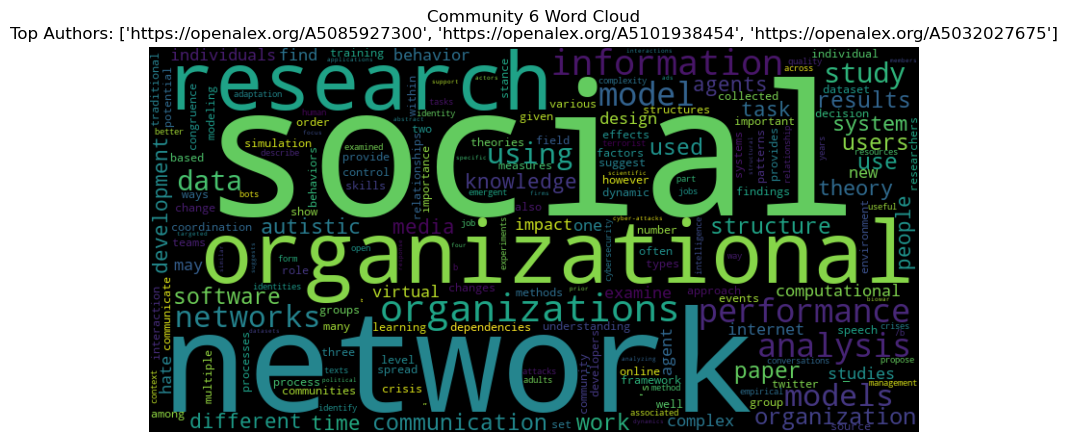

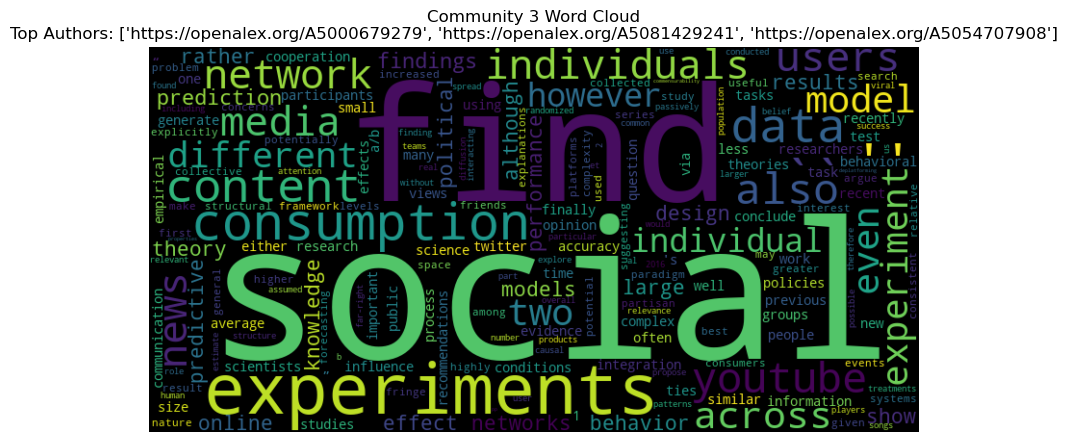

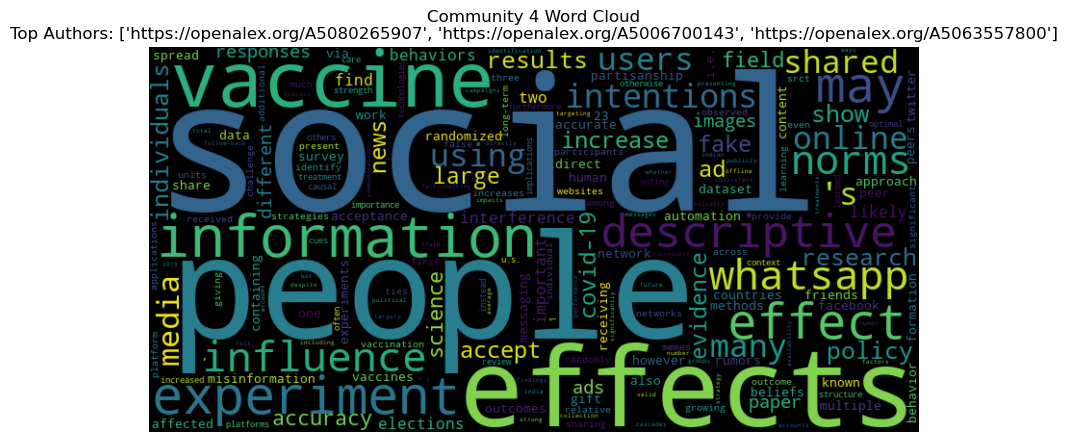

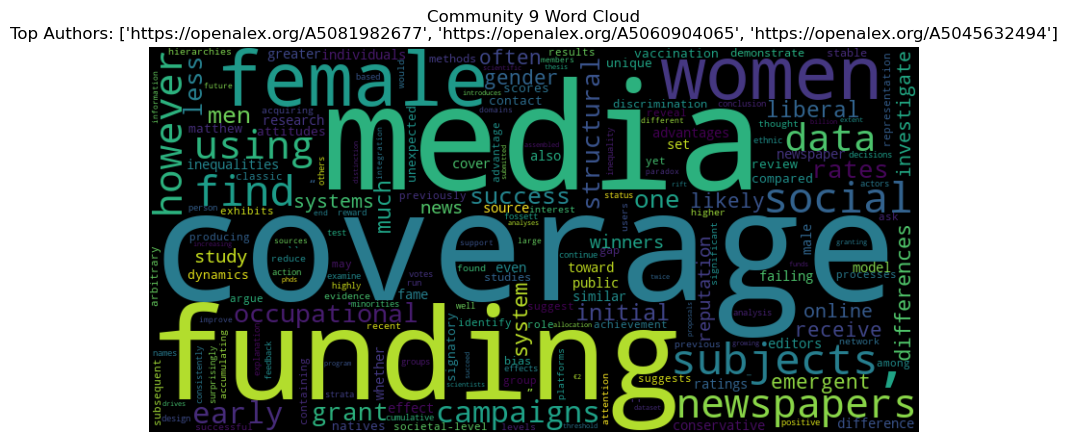

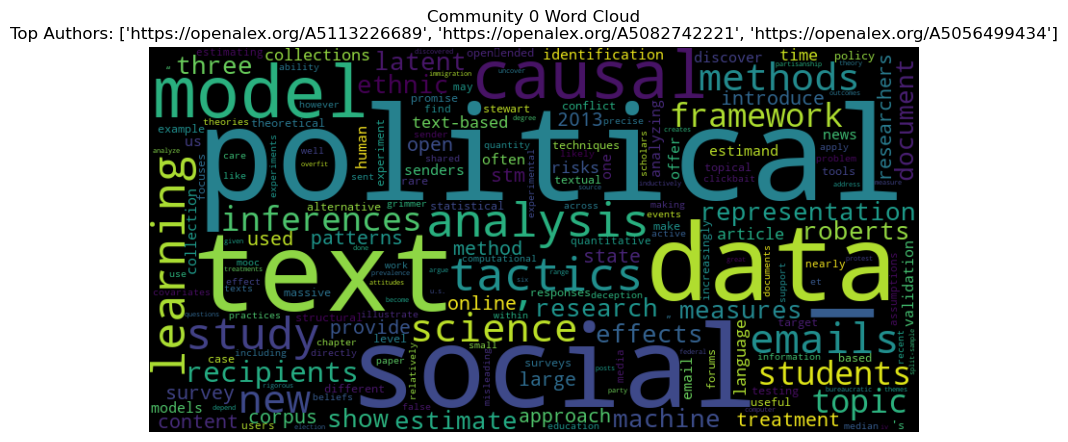

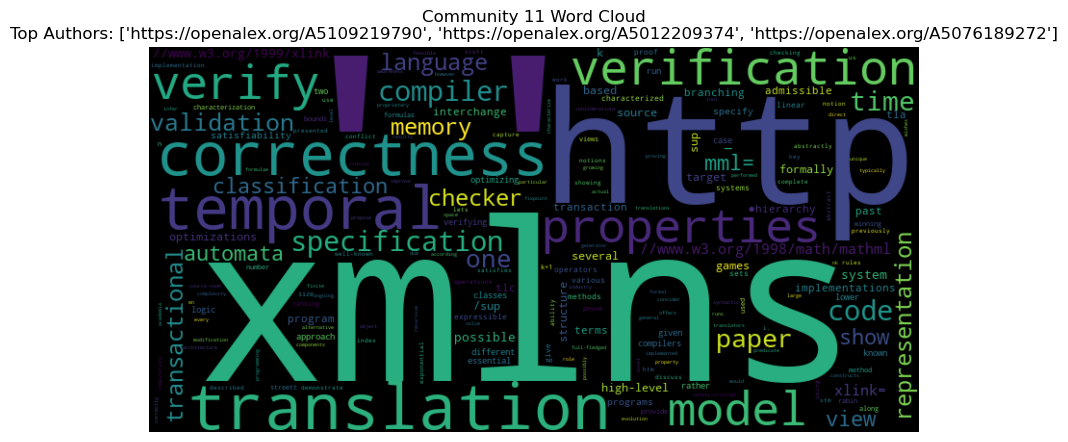

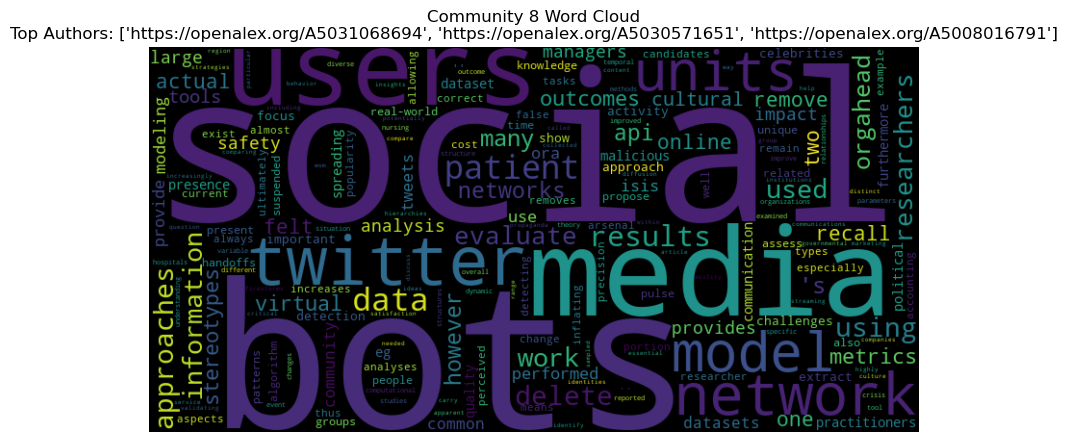

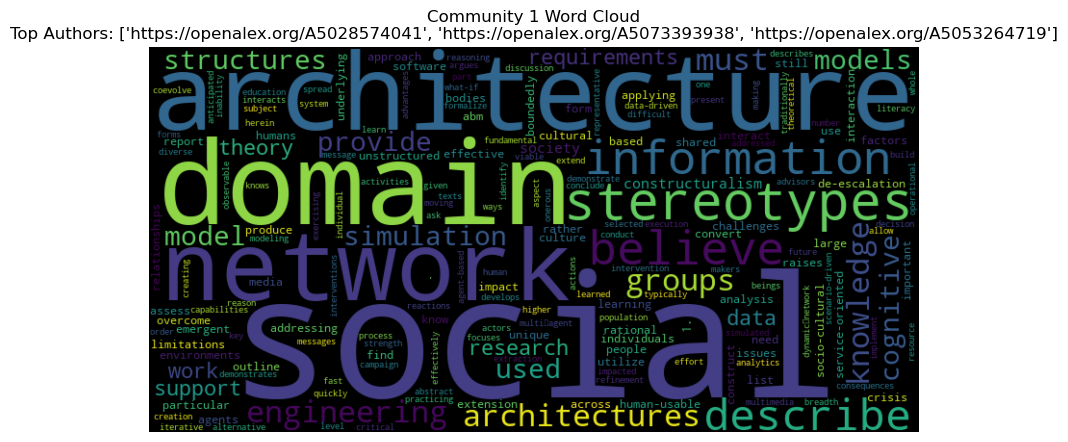

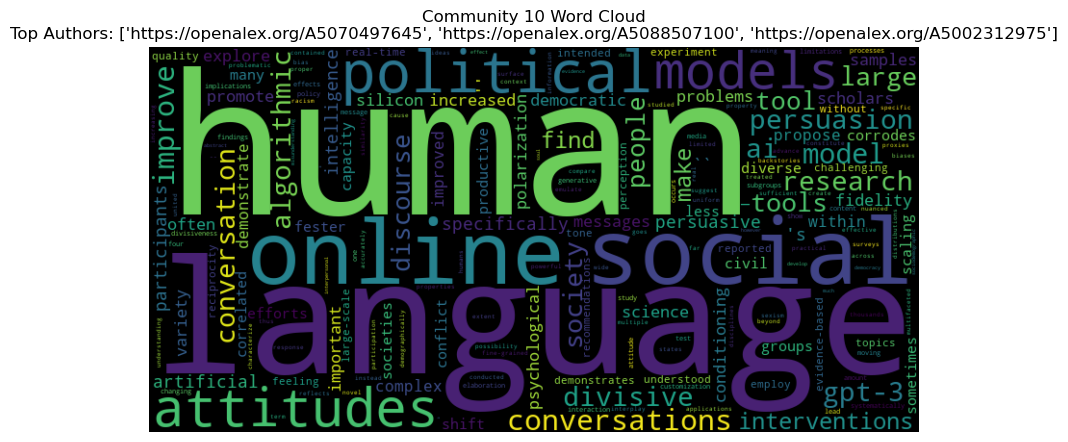

In [77]:
# Using wordcloud to visualize top words in every community
communities = community_df['community']
for comm in top_communities:
    wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(tf_community[comm])
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Community {comm} Word Cloud')
    # Show top three authors in the title
    top_authors = community_df[community_df['community'] == comm].sort_values(by='degree', ascending=False).head(3)
    author_ids = top_authors['author_id'].tolist()
    plt.title(f'Community {comm} Word Cloud\nTop Authors: {author_ids}')
    plt.show()
